# Synchronization

This notebook walks through the full receiver-side synchronization chain for a BPSK signal,
following the PySDR *Synchronization* chapter. We start by simulating a transmitted signal
with realistic impairments (a fractional timing offset and a frequency offset), then recover
it step by step:

1. Generate a pulse-shaped BPSK signal
2. Add a fractional-sample timing offset
3. Add a coarse frequency offset
4. Estimate and correct the coarse frequency offset (squaring method)
5. Symbol timing recovery (Mueller and Muller)
6. Fine frequency/phase sync (Costas loop) and BER check


## Create the BPSK signal

We generate random bits, map them to +1/-1, and space them out by `sps` samples per symbol
to form a pulse train (an impulse at the start of each symbol period).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Create BPSK signal
num_symbols = 100
sps = 8
bits = np.random.randint(0, 2, num_symbols) # Our data to be transmitted, 1's and 0's
pulse_train = np.array([])
for bit in bits:
    pulse = np.zeros(sps)
    pulse[0] = bit*2-1 # set the first value to either a 1 or -1
    pulse_train = np.concatenate((pulse_train, pulse)) # add the 8 samples to the signal

## Pulse shaping

We convolve the pulse train with a raised-cosine filter to limit the signal's bandwidth.

In [2]:
# Apply pulse shaping to the BPSK
num_taps = 101
beta = 0.35
Ts = sps # Assume sample rate is 1 Hz, so sample period is 1, so *symbol* period is 8
t = np.arange(-51, 52) # remember it's not inclusive of final number
h = np.sinc(t/Ts) * np.cos(np.pi*beta*t/Ts) / (1 - (2*beta*t/Ts)**2)
samples = np.convolve(pulse_train, h, 'same')

## Add a fractional timing offset

A real receiver never samples exactly at the symbol boundaries. We emulate that by applying a
fractional-delay filter, shifting the signal by a non-integer number of samples.

In [3]:
# Create and apply fractional delay filter to emulate a random timing offset
delay = 0.456 # fractional delay, in samples
N = 21 # number of taps, keep this odd
n = np.arange(-(N-1)//2, N//2+1) # -10,-9,...,0,...,9,10
h = np.sinc(n - delay) # calc filter taps
h *= np.hamming(N) # window the filter to make sure it decays to 0 on both sides
h /= np.sum(h) # normalize to get unity gain, we don't want to change the amplitude/power
samples = np.convolve(samples, h) # apply filter

## Add a coarse frequency offset

Transmitter and receiver oscillators are never perfectly aligned, which shows up as a frequency
offset. Here we deliberately add a large one (13 kHz) to be corrected later.

In [4]:
# Apply a pretty significant freq offset
fs = 1e6 # assume our sample rate is 1 MHz
fo = 13000 # simulate freq offset THIS REPRESENTS A COARSE OFFSET!
Ts = 1/fs # calc sample period
t = np.arange(0, Ts*len(samples), Ts) # create time vector
samples = samples * np.exp(1j*2*np.pi*fo*t) # perform freq shift

## Coarse frequency correction

Squaring a BPSK signal removes the data modulation and produces a tone at twice the frequency
offset. We find that tone's location in the FFT, halve it, and de-rotate the signal.

In [5]:
# Estimate and correct for the coarse freq offset
samples_sq = samples**2
psd = np.fft.fftshift(np.abs(np.fft.fft(samples_sq, 2048)))
f = np.linspace(-fs/2.0, fs/2.0, len(psd))
max_freq = f[np.argmax(psd)] / 2.0
print(f"Estimated freq offset: {max_freq:.2f} Hz")
Ts = 1/fs # calc sample period
t = np.arange(0, Ts*len(samples), Ts) # create time vector
samples = samples * np.exp(-1j*2*np.pi*max_freq*t)

# At this point there should be less than 1kHz of freq offset in our signal, depending how large an FFT you used above

Estimated freq offset: 13067.90 Hz


## Symbol timing recovery

We use the Mueller and Muller timing-error detector. An interpolating resampler lets us pick a
sub-sample-accurate point within each symbol, and the loop adjusts the sampling instant `mu`
to lock onto the symbol timing.

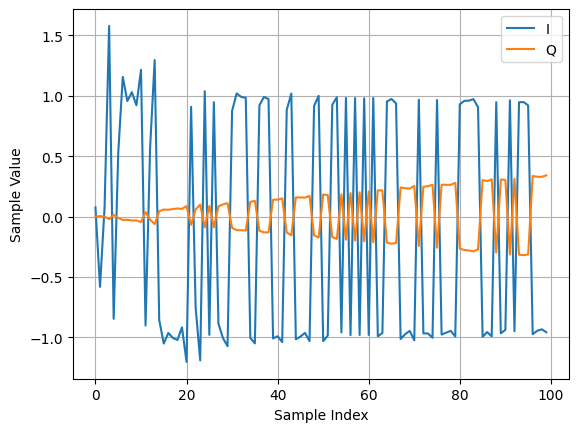

In [6]:
# Symbol/Timing Sync
mu = 0 # initial estimate of phase of sample
out = np.zeros(len(samples) // sps + 2, dtype=np.complex64)
out_rail = np.zeros(len(samples) // sps + 2, dtype=np.complex64) # stores values, each iteration we need the previous 2 values plus current value
i_in = 0 # input samples index
i_out = 2 # output index (let first two outputs be 0)
interpolation_factor = 16
samples_interpolated = signal.resample_poly(samples, interpolation_factor, 1)
while i_out < len(samples) and i_in+16 < len(samples):
    out[i_out] = samples_interpolated[i_in*interpolation_factor + int(mu*interpolation_factor)]
    out_rail[i_out] = int(np.real(out[i_out]) > 0) + 1j*int(np.imag(out[i_out]) > 0)
    x = (out_rail[i_out] - out_rail[i_out-2]) * np.conj(out[i_out-1])
    y = (out[i_out] - out[i_out-2]) * np.conj(out_rail[i_out-1])
    mm_val = np.real(y - x)
    mu += sps + 0.3*mm_val
    i_in += int(np.floor(mu)) # round down to nearest int since we are using it as an index
    mu = mu - np.floor(mu) # remove the integer part of mu
    i_out += 1 # increment output index
out = out[3:i_out] # remove the first few due to filter transients, and anything after i_out (that was never filled out)
samples = out

plt.figure(2)
plt.plot(np.real(samples))
plt.plot(np.imag(samples))
plt.xlabel('Sample Index')
plt.ylabel('Sample Value')
plt.legend(['I', 'Q'])
plt.grid()

## Fine frequency and phase sync (Costas loop)

The coarse correction leaves a small residual frequency/phase offset. A Costas loop tracks and
removes it. After it converges, we slice the bits, compute the bit error rate, and plot the
frequency estimate over time along with the recovered constellation.

Number of bit errors: 0 out of 100 bits, BER: 0.0000


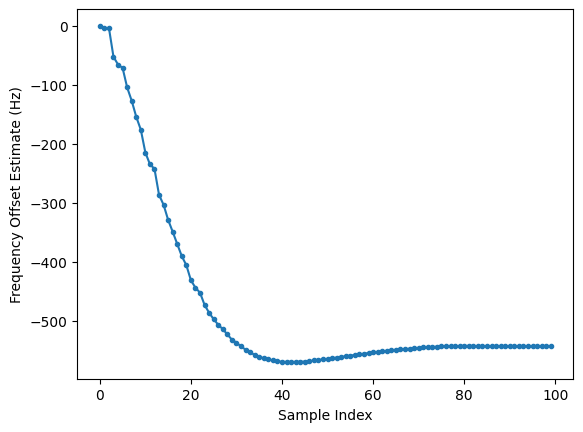

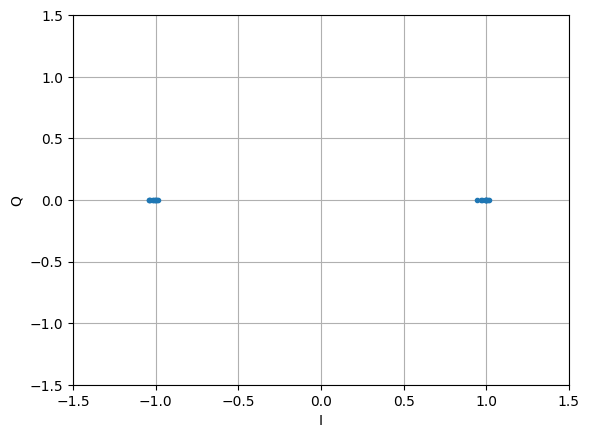

In [7]:
N = len(samples)
phase = 0
freq = 0
# These next two params is what to adjust, to make the feedback loop faster or slower (which impacts stability)
alpha = 0.132
beta = 0.00932
out = np.zeros(N, dtype=np.complex64)
freq_log = []
for i in range(N):
    out[i] = samples[i] * np.exp(-1j*phase) # adjust the input sample by the inverse of the estimated phase offset
    error = np.real(out[i]) * np.imag(out[i]) # This is the error formula for 2nd order Costas Loop (e.g. for BPSK)

    # Advance the loop (recalc phase and freq offset)
    freq += (beta * error)
    freq_log.append(freq * fs / (2*np.pi)) # convert from angular velocity to Hz for logging
    phase += freq + (alpha * error)

    # Optional: Adjust phase so its always between 0 and 2pi, recall that phase wraps around every 2pi
    while phase >= 2*np.pi:
        phase -= 2*np.pi
    while phase < 0:
        phase += 2*np.pi

# Calc BER
rx_bits = (np.real(out) > 0).astype(int)
num_bit_errors = np.sum(rx_bits != bits[:len(rx_bits)])
print(f"Number of bit errors: {num_bit_errors} out of {len(rx_bits)} bits, BER: {num_bit_errors/len(rx_bits):.4f}")

# Plot freq over time to see how long it takes to hit the right offset
plt.figure(0)
plt.plot(freq_log,'.-')
plt.xlabel('Sample Index')
plt.ylabel('Frequency Offset Estimate (Hz)')

# Appears to be synced after ~80 samples so lets plot the constellation of the remaining 20 samples
plt.figure(1)
plt.plot(np.real(out[80:]), np.imag(out[80:]), '.')
plt.xlabel('I')
plt.ylabel('Q')
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.grid()
plt.show()